In [1]:
import numpy as np
from PIL import Image
import cv2
import torch
import torch.nn
import torchvision.utils as vutils
from torch.utils.data import DataLoader
from torchvision import transforms
import torchvision.transforms.functional as TF
from statsmodels.nonparametric.smoothers_lowess import lowess
import matplotlib.pyplot as plt

In [2]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, img_name, transform):
        self.img_name = img_name
        self.transform = transform
        
    def __getitem__(self, index):
        img = Image.open(self.img_name)
        img = self.transform(img)
        return img
        
    def __len__(self):
        return len([self.img_name])

test_transform = transforms.Compose([transforms.Resize((256, 256)), transforms.Grayscale(num_output_channels=1), transforms.ToTensor()])

In [3]:
def find_keypoint(mask):
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
    skeleton = []
    skeleton_img = np.zeros(mask.shape, dtype=mask.dtype)
    for c in range(0, mask.shape[1]):
        tcol = mask[:, c]
        if np.any(tcol != 0):
            for r in range(1, mask.shape[0] - 1):
                if tcol[r - 1] == 0 and tcol[r] != 0:
                    idx1 = r
                if tcol[r + 1] == 0 and tcol[r] != 0:
                    idx2 = r
                    break
                else:
                    continue
            skeleton.append(mask.shape[0] - round((idx1 + idx2) / 2))
            bl = idx2 - idx1 + 1
            if bl < 13:
                skeleton_img[idx1:idx2 + 1, c] = 255
            else:
                skeleton_img[round((idx1 + idx2) / 2) - 6:round((idx1 + idx2) / 2) + 7, c] = 255
        else:
            skeleton.append(0)

    data = [x / 12 for x in skeleton]
    non_zero_indices = np.where(np.array(data) != 0)[0]
    non_zero_values = np.array(data)[non_zero_indices]
    zero_indices = np.where(np.array(data) == 0)[0]
    middle_zero_indices = zero_indices[(zero_indices > non_zero_indices[0]) & (zero_indices < non_zero_indices[-1])]
    interpolated_values = np.interp(middle_zero_indices, non_zero_indices, non_zero_values)
    interpolated_data = np.array(data)
    interpolated_data[middle_zero_indices] = interpolated_values

    smoothed = lowess(interpolated_data[non_zero_indices[0]:non_zero_indices[-1] + 1],
                      np.arange(non_zero_indices[0], non_zero_indices[-1] + 1), frac=0.1)
    peak_points, trough_points = [], []
    for i in range(1, smoothed.shape[0] - 1):
        if smoothed[i, 1] > smoothed[i - 1, 1] and smoothed[i, 1] > smoothed[i + 1, 1]:
            peak_points.append((smoothed[i, 0], smoothed[i, 1]))
        if smoothed[i, 1] < smoothed[i - 1, 1] and smoothed[i, 1] < smoothed[i + 1, 1]:
            trough_points.append((smoothed[i, 0], smoothed[i, 1]))

    if len(trough_points) != 0:
        for ti in range(0, len(trough_points)):
            target = trough_points[ti]
            left_points = []
            right_points = []
            for point in peak_points:
                if point[0] < target[0]:
                    left_points.append(point)
                elif point[0] > target[0]:
                    right_points.append(point)
            if not left_points:
                closest_right = min(right_points, key=lambda x: abs(x[0] - target[0]))
                if 0.15 < closest_right[1] - target[1] < 3:
                    key_points = [target + closest_right]
                else:
                    key_points = False
            elif not right_points:
                closest_left = max(left_points, key=lambda x: abs(x[0] - target[0]))
                if 0.15 < closest_left[1] - target[1] < 3:
                    key_points = [target + closest_left]
                else:
                    key_points = False
            else:
                closest_left = max(left_points, key=lambda x: x[0])
                closest_right = min(right_points, key=lambda x: abs(x[0] - target[0]))
                if 0.15 < closest_left[1] - target[1] < 3 and 0.15 < closest_right[1] - target[1] < 3:
                    if closest_left[1] - target[1] < closest_right[1] - target[1]:
                        key_points = [target + closest_left]
                    else:
                        key_points = [target + closest_right]
                elif 0.15 < closest_left[1] - target[1] < 3 and not 0.15 < closest_right[1] - target[1] < 3:
                    key_points = [target + closest_left]
                elif not 0.15 < closest_left[1] - target[1] < 3 and 0.15 < closest_right[1] - target[1] < 3:
                    key_points = [target + closest_right]
                else:
                    key_points = False
            if key_points:
                break
    else:
        key_points = False

    x_non_zero = np.arange(len(interpolated_data))[interpolated_data != 0]
    plt.scatter(x_non_zero, interpolated_data[interpolated_data != 0], marker='.', label='Original Data', color='seagreen')
    plt.plot(smoothed[:, 0], smoothed[:, 1], label='Smoothed Curve', color='mediumslateblue')
    if key_points:
        plt.scatter(key_points[0][0], key_points[0][1], label='Trough', color='black', s=50)
        plt.scatter(key_points[0][2], key_points[0][3], label='Peak', color='red', s=50)
    else:
        for ti in range(0, len(trough_points)):
            plt.scatter(trough_points[ti][0], trough_points[ti][1], label='Trough', color='black', s=50)
        for pi in range(0, len(peak_points)):
            plt.scatter(peak_points[pi][0], peak_points[pi][1], label='Peak', color='red', s=50)
    plt.title('Diaphragm Movement Curve', fontsize=11)
    plt.legend()
    plt.xlim(0, len(interpolated_data))
    plt.yticks([])
    plt.savefig('Diaphragm Movement Curve.png')
    plt.show()
    # plt.close()

    return skeleton_img, key_points


In [ ]:
test_dataset = Dataset(img_name = 'image1.png', transform=test_transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=False)
device = torch.device("cuda")
model = torch.load('segmodel1.pt')
model = model.to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2, momentum=0.9)
model.eval()
test_img = next(iter(test_loader)).to(device)
optimizer.zero_grad()
with torch.set_grad_enabled(False):
    out_img = model(test_img)
    out_img = torch.round(out_img)[0, :, :, :].cpu()
    out_img = cv2.cvtColor((out_img.numpy() * 255).astype(np.uint8).transpose((1, 2, 0)), cv2.COLOR_RGB2BGR)

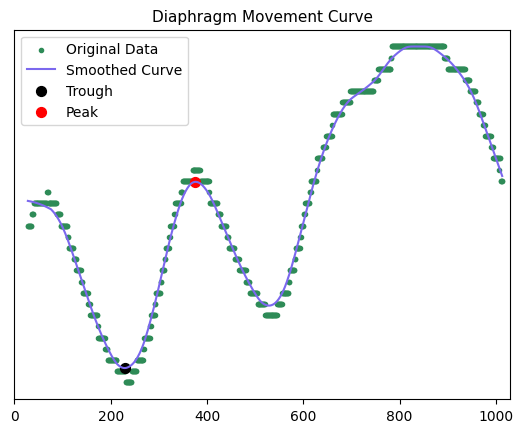

diaphragm excursion: 1.3855761663936113 (cm) 
diaphragm contraction duration: 1.47 (s) 
diaphragm contraction velocity: 0.9425688206759261 (cm/s)


In [5]:
img = cv2.imread('image1.png')
mask = cv2.resize(out_img, dsize=(img.shape[1], img.shape[0]), fx=1, fy=1, interpolation=cv2.INTER_LINEAR)
_, mask = cv2.threshold(mask, 100, 255, cv2.THRESH_BINARY)
skeleton_img, key_points = find_keypoint(mask)
# cv2.imwrite('image1_seg.png', skeleton_img)
DE = key_points[0][3] - key_points[0][1]
DCD = abs(key_points[0][2] - key_points[0][0]) / 100
DCV = DE / DCD
print('diaphragm excursion:', DE, '(cm)',
      '\ndiaphragm contraction duration:', DCD, '(s)', 
      '\ndiaphragm contraction velocity:', DCV, '(cm/s)')